# So sánh Raw Data: Self-Collected vs Public Datasets

So sánh **hoạt động Normal (ADL)** giữa:
1. **Self-collected** – ESP32-C3 + MPU6050, 50Hz, Kalman-filtered, accel (m/s²), gyro (rad/s)
2. **BandX-Activity** – MPU6050, 20Hz, raw, accel (m/s²), gyro (rad/s)
3. **HR_IMU** – Wrist IMU, 50Hz, accel (**g, gravity-removed**), gyro (angular velocity)

> **Lưu ý**: HR_IMU đã bị **loại bỏ trọng lực (gravity-removed)** và đơn vị accel là **g** (không phải m/s²). Cần convert để so sánh.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

# ==================== PATHS ====================
# Điều chỉnh nếu chạy trên Colab
BASE = '..'  # Từ Comparison/ lên PBL5/
COLLECTED_DIR = os.path.join(BASE, 'server', 'data', 'collected', 'Normal')
BANDX_RAW     = os.path.join(BASE, 'public_data', 'BandX-Activity', 'BandX-Data', 'raw_data')
HRIMU_DIR     = os.path.join(BASE, 'public_data', 'HR_IMU_falldetection_dataset-master',
                             'HR_IMU_falldetection_dataset-master')

print('Collected sessions:', len(os.listdir(COLLECTED_DIR)) if os.path.isdir(COLLECTED_DIR) else 0)
print('BandX users:', len(glob.glob(os.path.join(BANDX_RAW, 'user*.csv'))))
print('HR_IMU subjects:', len(glob.glob(os.path.join(HRIMU_DIR, 'subject_*'))))

Collected sessions: 6
BandX users: 33
HR_IMU subjects: 21


## 1. Load Self-Collected Data (Normal sessions)

In [2]:
def load_collected_sessions(collected_dir):
    """Load tất cả session Normal đã thu, trả về DataFrame raw accel + gyro."""
    frames = []
    sessions = sorted(os.listdir(collected_dir))
    for sess in sessions:
        accel_path = os.path.join(collected_dir, sess, 'accel.csv')
        gyro_path  = os.path.join(collected_dir, sess, 'gyro.csv')
        if not os.path.exists(accel_path) or not os.path.exists(gyro_path):
            continue
        accel = pd.read_csv(accel_path)
        gyro  = pd.read_csv(gyro_path)
        # Merge trên index (cùng thứ tự sample)
        df = pd.DataFrame({
            'time': accel.iloc[:, 0],
            'ax': accel.iloc[:, 1],
            'ay': accel.iloc[:, 2],
            'az': accel.iloc[:, 3],
            'gx': gyro.iloc[:, 1],
            'gy': gyro.iloc[:, 2],
            'gz': gyro.iloc[:, 3],
        })
        df['session'] = sess
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

df_collected = load_collected_sessions(COLLECTED_DIR)
# Đơn vị: accel = m/s² (Kalman-filtered), gyro = rad/s
# Tính magnitude
df_collected['mag'] = np.sqrt(df_collected['ax']**2 + df_collected['ay']**2 + df_collected['az']**2)
df_collected['gmag'] = np.sqrt(df_collected['gx']**2 + df_collected['gy']**2 + df_collected['gz']**2)
print(f'Self-Collected: {len(df_collected)} samples, {df_collected["session"].nunique()} sessions')
df_collected[['ax','ay','az','gx','gy','gz','mag']].describe().round(3)

Self-Collected: 5000 samples, 6 sessions


,ax,ay,az,gx,gy,gz,mag
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,-5.896,-1.673,5.075,-0.045,0.046,0.086,9.676
std,4.221,1.658,3.183,0.523,0.253,0.347,0.614
min,-8.990,-5.666,-1.611,-2.211,-0.762,-0.557,7.685
25%,-8.591,-2.590,2.914,-0.213,-0.054,-0.093,9.361
50%,-8.302,-2.084,3.547,-0.036,0.028,-0.007,9.463
75%,-4.085,-1.069,7.283,0.133,0.108,0.126,9.961
max,8.084,4.226,13.120,2.556,1.400,1.943,13.698


## 2. Load BandX-Activity (Normal activities only)

BandX gồm: Walking(Wa), Jogging(J), Typing(T), Writing(Wr), Upstairs(U), Downstairs(D), Cycling(C).  
Tất cả đều là **Normal/ADL** → lấy hết.

In [3]:
def load_bandx(raw_dir, max_users=10):
    """Load BandX raw data, giữ nguyên đơn vị gốc (m/s² accel, rad/s gyro)."""
    files = sorted(glob.glob(os.path.join(raw_dir, 'user*.csv')))
    frames = []
    for f in files[:max_users]:
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()
        df['user'] = os.path.basename(f).replace('.csv', '')
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

df_bandx = load_bandx(BANDX_RAW, max_users=10)
# Đơn vị gốc: accel m/s², gyro rad/s (MPU6050 raw)
df_bandx['mag'] = np.sqrt(df_bandx['ax']**2 + df_bandx['ay']**2 + df_bandx['az']**2)
df_bandx['gmag'] = np.sqrt(df_bandx['gx']**2 + df_bandx['gy']**2 + df_bandx['gz']**2)

print(f'BandX: {len(df_bandx)} samples, {df_bandx["user"].nunique()} users')
print(f'Activities: {df_bandx["label"].unique()}')
df_bandx[['ax','ay','az','gx','gy','gz','mag']].describe().round(3)

BandX: 131769 samples, 10 users
Activities: ['Wa' 'J' 'T' 'Wr' 'U' 'D' 'C']


,ax,ay,az,gx,gy,gz,mag
count,131769.000,131769.000,131769.000,131769.000,131769.000,131769.000,131769.000
mean,4.133,1.503,5.299,-0.048,-0.079,-0.013,10.750
std,4.489,6.238,4.190,0.826,0.967,1.107,2.912
min,-19.613,-19.613,-19.613,-4.366,-4.366,-4.366,0.693
25%,1.279,-2.212,1.882,-0.248,-0.402,-0.254,9.604
50%,3.103,0.747,6.273,-0.053,-0.060,-0.010,10.260
75%,6.627,6.201,8.894,0.147,0.261,0.227,11.163
max,19.613,30.000,30.000,6.258,4.366,7.594,42.480


## 3. Load HR_IMU (Non-fall / Normal activities only)

**⚠️ QUAN TRỌNG**: README ghi rõ *"An Effectiveness of gravity is removed"*  
→ Accel đã bị **trừ trọng lực**, đơn vị **g** (không phải m/s²).  
→ Khi nằm yên, magnitude ≈ **0g** thay vì ≈ 1g.  
→ Đây là **data đã pre-processed**, KHÔNG phải raw.

In [6]:
def load_hrimu_nonfall(hrimu_dir, max_subjects=10):
    """Load HR_IMU non-fall .mat files.
    Mỗi file .mat chứa các key riêng: ax, ay, az, droll, dpitch, dyaw, ...
    Accel: đơn vị g (gravity-removed). Gyro: droll, dpitch, dyaw (deg/s)."""
    subjects = sorted(glob.glob(os.path.join(hrimu_dir, 'subject_*')))
    frames = []
    for subj in subjects[:max_subjects]:
        nonfall_dir = os.path.join(subj, 'non-fall')
        if not os.path.isdir(nonfall_dir):
            continue
        for mat_file in sorted(glob.glob(os.path.join(nonfall_dir, '*.mat'))):
            try:
                mat = sio.loadmat(mat_file)
                # Kiểm tra có đủ key không
                required = ['ax', 'ay', 'az', 'droll', 'dpitch', 'dyaw']
                if not all(k in mat for k in required):
                    print(f'  Skip {mat_file}: missing keys')
                    continue
                df = pd.DataFrame({
                    'ax': mat['ax'].flatten(),      # g (gravity-removed)
                    'ay': mat['ay'].flatten(),
                    'az': mat['az'].flatten(),
                    'gx': mat['droll'].flatten(),    # angular velocity (deg/s)
                    'gy': mat['dpitch'].flatten(),
                    'gz': mat['dyaw'].flatten(),
                })
                activity = os.path.splitext(os.path.basename(mat_file))[0]
                df['activity'] = activity
                df['subject'] = os.path.basename(subj)
                frames.append(df)
            except Exception as e:
                print(f'  Skip {mat_file}: {e}')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

df_hrimu = load_hrimu_nonfall(HRIMU_DIR, max_subjects=10)
# Đơn vị: accel = g (GRAVITY REMOVED), gyro = angular velocity (deg/s)
df_hrimu['mag'] = np.sqrt(df_hrimu['ax']**2 + df_hrimu['ay']**2 + df_hrimu['az']**2)
df_hrimu['gmag'] = np.sqrt(df_hrimu['gx']**2 + df_hrimu['gy']**2 + df_hrimu['gz']**2)

print(f'HR_IMU: {len(df_hrimu)} samples, {df_hrimu["subject"].nunique()} subjects')
print(f'Activities: {df_hrimu["activity"].unique()}')
df_hrimu[['ax','ay','az','gx','gy','gz','mag']].describe().round(4)

HR_IMU: 140470 samples, 10 subjects
Activities: ['chair' 'clap' 'cloth' 'eat' 'hair' 'shoe' 'stair' 'teeth' 'walk' 'wash'
 'write' 'zip' 'bed']


,ax,ay,az,gx,gy,gz,mag
count,140470.0000,140470.0000,140470.0000,140470.0000,140470.0000,140470.0000,140470.0000
mean,-0.0559,0.0174,-0.0206,0.5431,1.0197,0.6676,0.3471
std,0.2647,0.3399,0.2965,89.9262,54.7006,81.9752,0.3960
min,-16.2050,-15.6520,-5.8890,-1111.5000,-409.4000,-430.8000,0.0000
25%,-0.1260,-0.0890,-0.1080,-28.1000,-18.5000,-25.7000,0.0839
50%,-0.0040,0.0080,-0.0050,0.0000,0.0000,0.1000,0.2463
75%,0.0330,0.1310,0.0670,30.3000,20.3000,24.9000,0.5004
max,4.9070,9.4300,16.3710,1271.0000,964.0000,568.5000,25.9102


## 4. Kiểm chứng HR_IMU đã bị gravity-removed

Nếu raw (có trọng lực): magnitude lúc yên ≈ 1g (9.81 m/s²)  
Nếu gravity-removed: magnitude lúc yên ≈ 0g  

So sánh trực tiếp median magnitude của 3 dataset để confirm.

In [7]:
print('=' * 55)
print('KIỂM TRA GRAVITY TRONG ACCEL DATA')
print('=' * 55)

if not df_collected.empty:
    med_c = df_collected['mag'].median()
    print(f'\n✅ Self-Collected (m/s², Kalman-filtered):')
    print(f'   Median magnitude = {med_c:.2f} m/s²')
    print(f'   → {"CÓ trọng lực (≈9.81)" if med_c > 5 else "KHÔNG có trọng lực"}')

med_b = df_bandx['mag'].median()
print(f'\n✅ BandX-Activity (m/s², raw MPU6050):')
print(f'   Median magnitude = {med_b:.2f} m/s²')
print(f'   → {"CÓ trọng lực (≈9.81)" if med_b > 5 else "KHÔNG có trọng lực"}')

if not df_hrimu.empty:
    med_h = df_hrimu['mag'].median()
    print(f'\n⚠️  HR_IMU (đơn vị g, claimed gravity-removed):')
    print(f'   Median magnitude = {med_h:.4f} g')
    if med_h < 0.5:
        print(f'   → CONFIRMED: Đã bị LOẠI BỎ TRỌNG LỰC (median ≈ 0)')
        print(f'   → KHÔNG phải raw data, KHÔNG thể so sánh trực tiếp!')
    else:
        print(f'   → CHƯA bị loại bỏ trọng lực? (median > 0.5g)')
    # Thử convert về m/s² có gravity: raw = measured - gravity
    # → Không thể khôi phục chính xác vì không biết hướng trọng lực
    print(f'\n   📊 HR_IMU accel stats (g):')
    print(f'   ax: mean={df_hrimu["ax"].mean():.4f}, std={df_hrimu["ax"].std():.4f}')
    print(f'   ay: mean={df_hrimu["ay"].mean():.4f}, std={df_hrimu["ay"].std():.4f}')
    print(f'   az: mean={df_hrimu["az"].mean():.4f}, std={df_hrimu["az"].std():.4f}')

KIỂM TRA GRAVITY TRONG ACCEL DATA

✅ Self-Collected (m/s², Kalman-filtered):
   Median magnitude = 9.46 m/s²
   → CÓ trọng lực (≈9.81)

✅ BandX-Activity (m/s², raw MPU6050):
   Median magnitude = 10.26 m/s²
   → CÓ trọng lực (≈9.81)

⚠️  HR_IMU (đơn vị g, claimed gravity-removed):
   Median magnitude = 0.2463 g
   → CONFIRMED: Đã bị LOẠI BỎ TRỌNG LỰC (median ≈ 0)
   → KHÔNG phải raw data, KHÔNG thể so sánh trực tiếp!

   📊 HR_IMU accel stats (g):
   ax: mean=-0.0559, std=0.2647
   ay: mean=0.0174, std=0.3399
   az: mean=-0.0206, std=0.2965


## 5. Chuẩn hóa đơn vị để so sánh

Để so sánh raw fair:
- **Self-Collected** và **BandX**: giữ nguyên (m/s², có gravity)
- **HR_IMU**: convert g → m/s² (`×9.81`), nhưng **vẫn thiếu gravity** → ghi chú rõ

Ta sẽ hiện cả 2 cách: (a) giữ nguyên, (b) HR_IMU × 9.81 + note gravity-removed.

In [8]:
# Convert HR_IMU: g → m/s² (vẫn thiếu gravity component)
G = 9.81
df_hrimu_ms2 = df_hrimu.copy()
for col in ['ax', 'ay', 'az']:
    df_hrimu_ms2[col] = df_hrimu_ms2[col] * G
df_hrimu_ms2['mag'] = df_hrimu_ms2['mag'] * G

print('HR_IMU sau convert (m/s², gravity-removed):')
df_hrimu_ms2[['ax','ay','az','mag']].describe().round(3)

HR_IMU sau convert (m/s², gravity-removed):


,ax,ay,az,mag
count,140470.000,140470.000,140470.000,140470.000
mean,-0.549,0.171,-0.202,3.405
std,2.596,3.334,2.908,3.885
min,-158.971,-153.546,-57.771,0.000
25%,-1.236,-0.873,-1.059,0.823
50%,-0.039,0.078,-0.049,2.416
75%,0.324,1.285,0.657,4.909
max,48.138,92.508,160.600,254.179


## 6. So sánh phân phối Accel Magnitude (Raw)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3840924936.py:32: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3840924936.py:32: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3840924936.py:33: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('magnitude_distribution_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3840924936.py:33: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('magnitude_distribution_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\

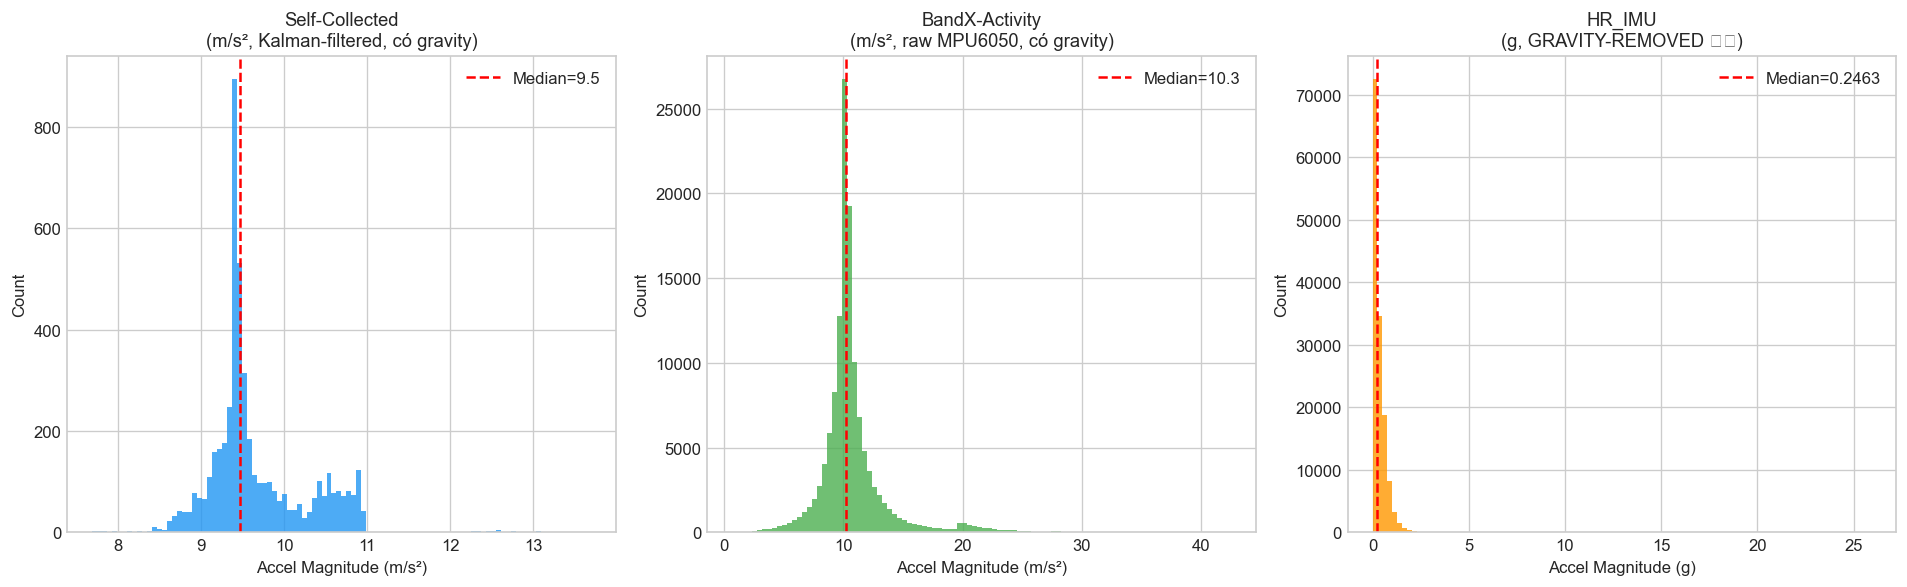


💡 Self-Collected & BandX: peak ≈ 9.8 m/s² (gravity). HR_IMU: peak ≈ 0g (gravity removed).


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Self-Collected ---
if not df_collected.empty:
    axes[0].hist(df_collected['mag'], bins=100, alpha=0.8, color='#2196F3', edgecolor='none')
    axes[0].axvline(df_collected['mag'].median(), color='red', ls='--', label=f'Median={df_collected["mag"].median():.1f}')
    axes[0].set_title('Self-Collected\n(m/s², Kalman-filtered, có gravity)', fontsize=11)
    axes[0].set_xlabel('Accel Magnitude (m/s²)')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Self-Collected')

# --- BandX ---
axes[1].hist(df_bandx['mag'], bins=100, alpha=0.8, color='#4CAF50', edgecolor='none')
axes[1].axvline(df_bandx['mag'].median(), color='red', ls='--', label=f'Median={df_bandx["mag"].median():.1f}')
axes[1].set_title('BandX-Activity\n(m/s², raw MPU6050, có gravity)', fontsize=11)
axes[1].set_xlabel('Accel Magnitude (m/s²)')
axes[1].legend()

# --- HR_IMU ---
if not df_hrimu.empty:
    axes[2].hist(df_hrimu['mag'], bins=100, alpha=0.8, color='#FF9800', edgecolor='none')
    axes[2].axvline(df_hrimu['mag'].median(), color='red', ls='--', label=f'Median={df_hrimu["mag"].median():.4f}')
    axes[2].set_title('HR_IMU\n(g, GRAVITY-REMOVED ⚠️)', fontsize=11)
    axes[2].set_xlabel('Accel Magnitude (g)')
    axes[2].legend()

for ax in axes:
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('magnitude_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Self-Collected & BandX: peak ≈ 9.8 m/s² (gravity). HR_IMU: peak ≈ 0g (gravity removed).')

## 7. So sánh phân phối từng trục Accel (ax, ay, az)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\2893784672.py:32: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\2893784672.py:32: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\2893784672.py:33: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('per_axis_accel_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\2893784672.py:33: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('per_axis_accel_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Ro

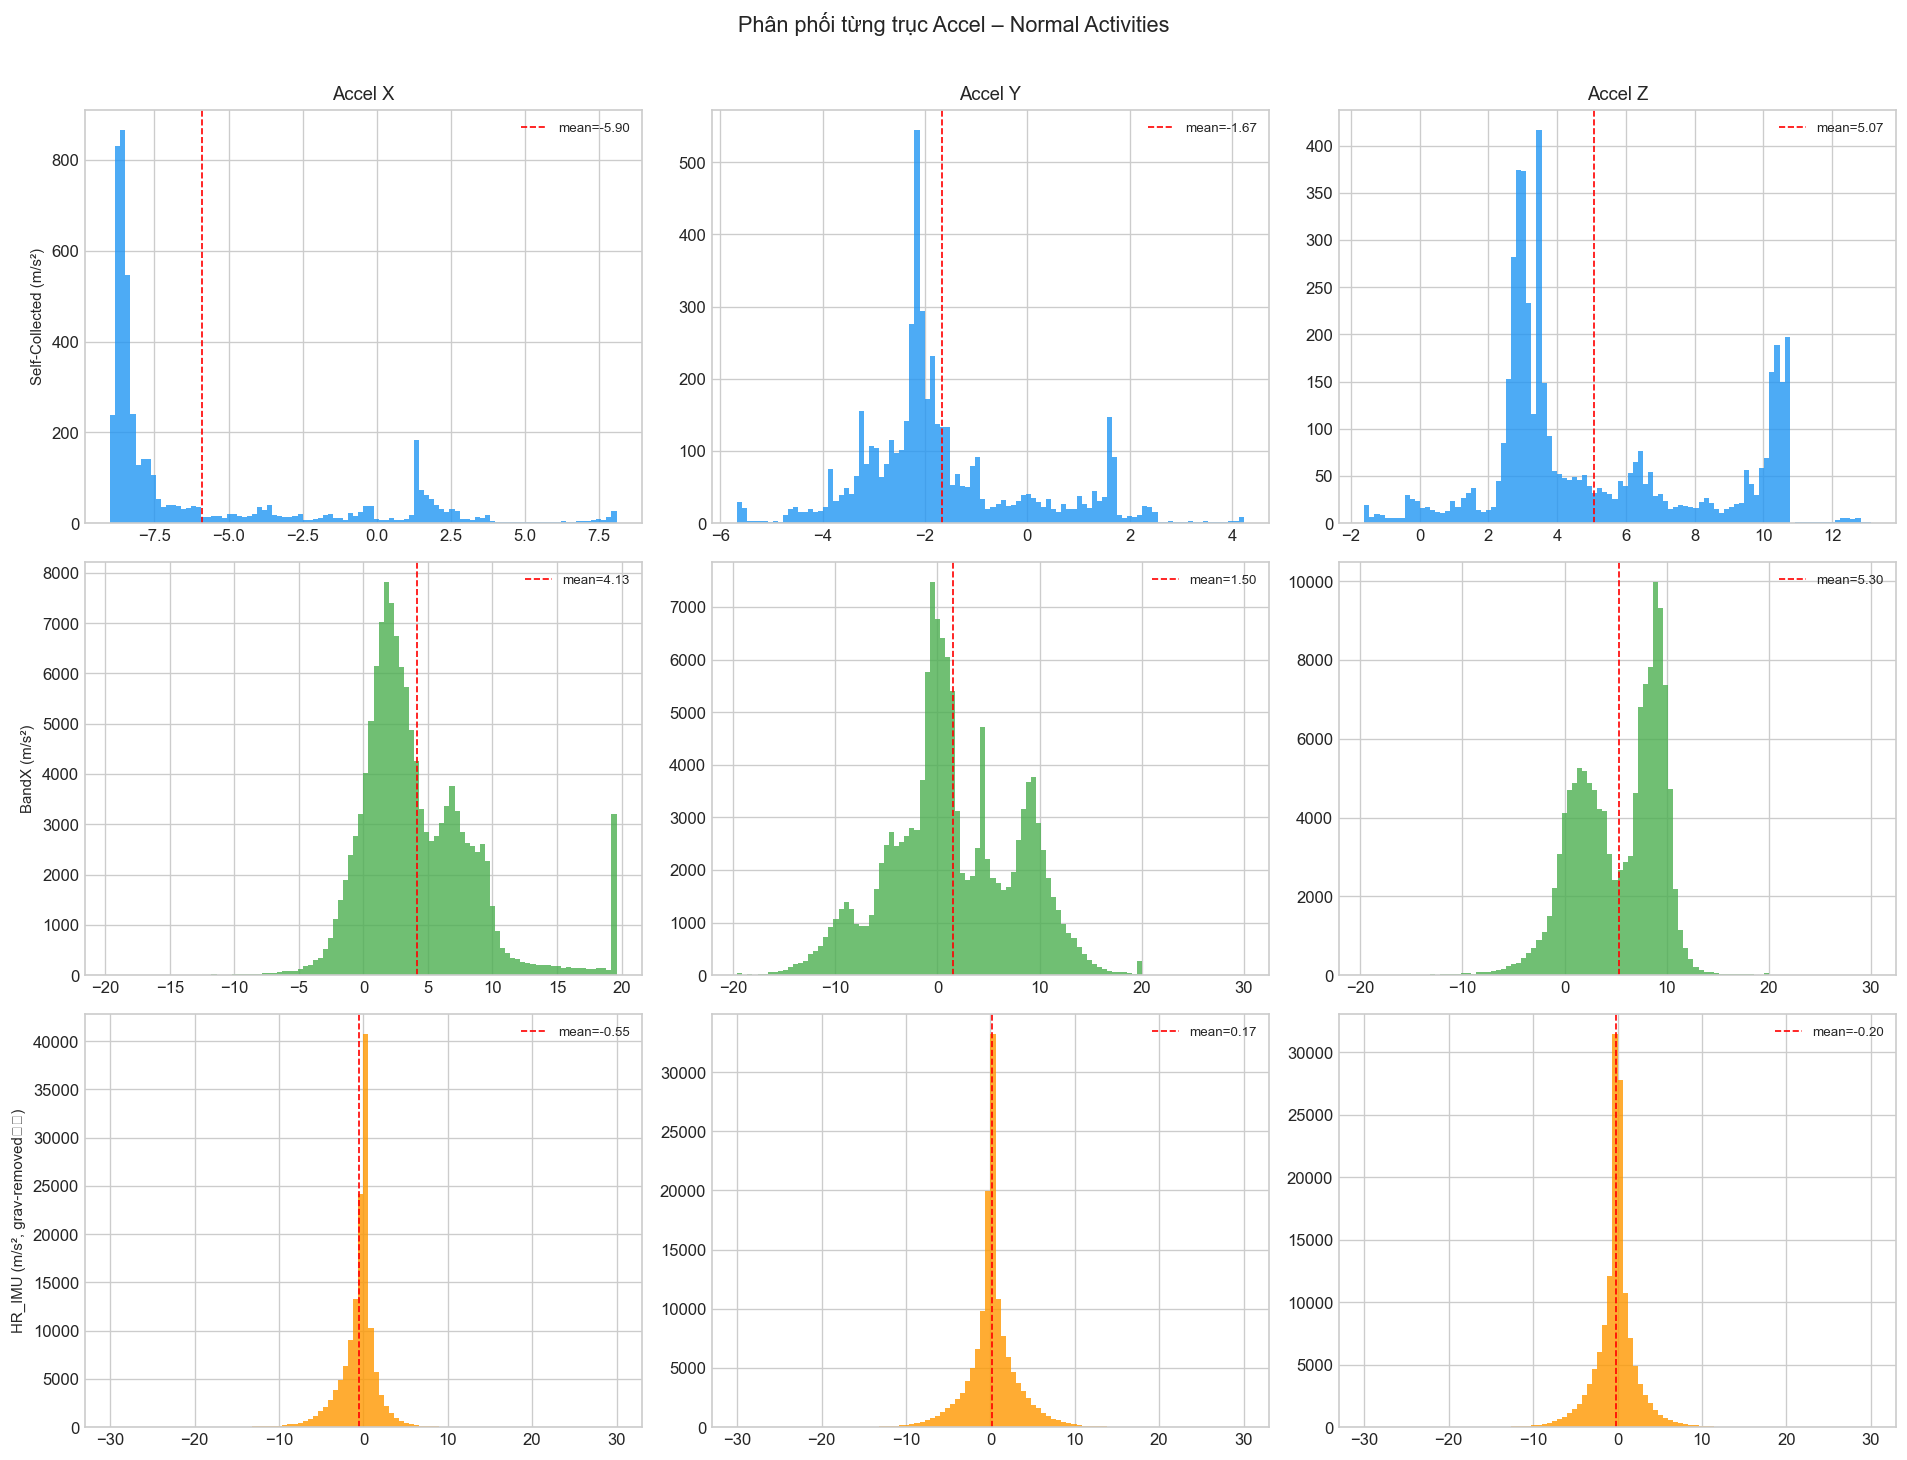

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

datasets = []
labels_list = []
colors = []
if not df_collected.empty:
    datasets.append(df_collected)
    labels_list.append('Self-Collected (m/s²)')
    colors.append('#2196F3')
datasets.append(df_bandx)
labels_list.append('BandX (m/s²)')
colors.append('#4CAF50')
if not df_hrimu.empty:
    datasets.append(df_hrimu_ms2)  # converted to m/s² for visual comparison
    labels_list.append('HR_IMU (m/s², grav-removed⚠️)')
    colors.append('#FF9800')

accel_cols = ['ax', 'ay', 'az']
accel_names = ['Accel X', 'Accel Y', 'Accel Z']

for i, ds in enumerate(datasets):
    for j, col in enumerate(accel_cols):
        axes[i, j].hist(ds[col].clip(-30, 30), bins=100, alpha=0.8, color=colors[i], edgecolor='none')
        axes[i, j].axvline(ds[col].mean(), color='red', ls='--', lw=1, label=f'mean={ds[col].mean():.2f}')
        axes[i, j].legend(fontsize=8)
        if j == 0:
            axes[i, j].set_ylabel(labels_list[i], fontsize=9)
        if i == 0:
            axes[i, j].set_title(accel_names[j], fontsize=11)

plt.suptitle('Phân phối từng trục Accel – Normal Activities', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('per_axis_accel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. So sánh Gyroscope Magnitude

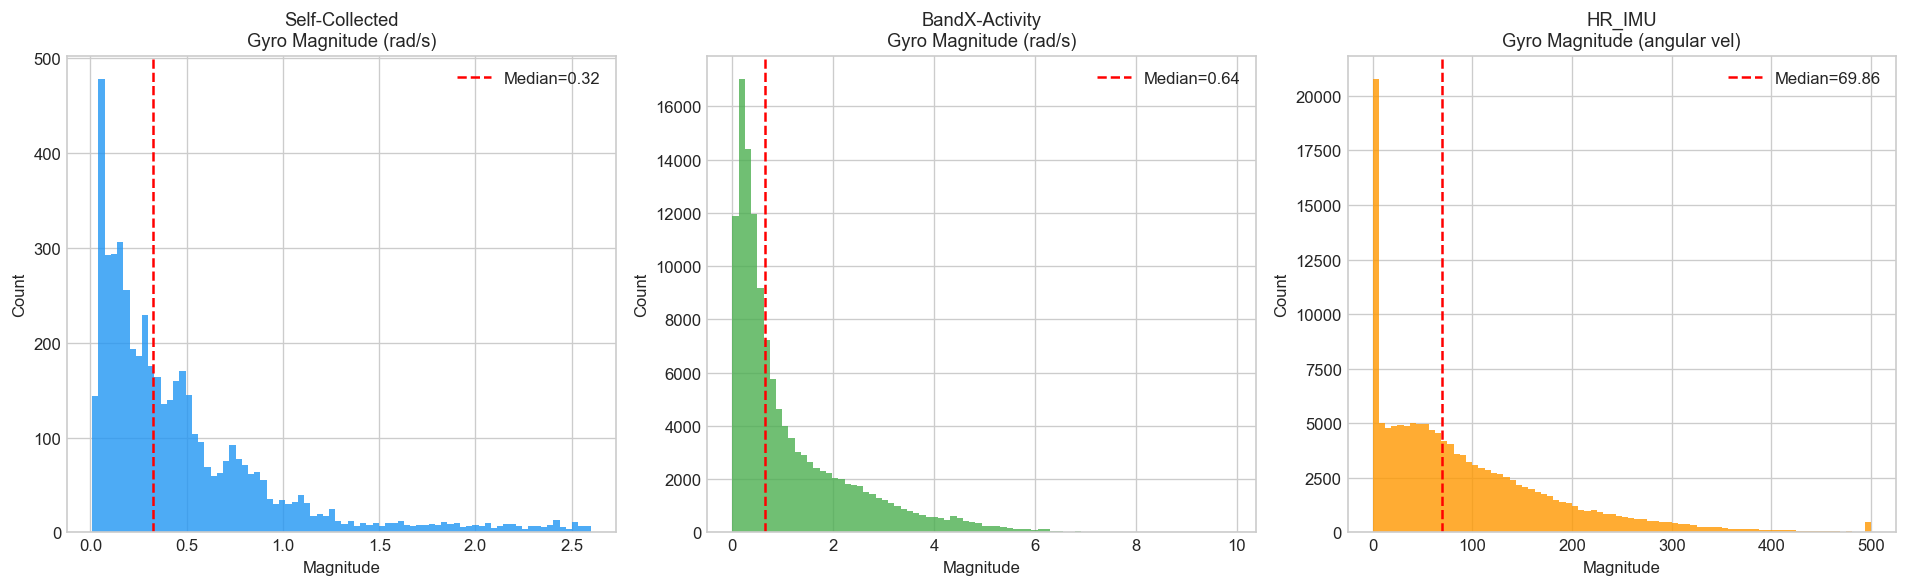

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

if not df_collected.empty:
    axes[0].hist(df_collected['gmag'].clip(0, 10), bins=80, alpha=0.8, color='#2196F3', edgecolor='none')
    axes[0].axvline(df_collected['gmag'].median(), color='red', ls='--', label=f'Median={df_collected["gmag"].median():.2f}')
    axes[0].set_title('Self-Collected\nGyro Magnitude (rad/s)', fontsize=11)
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Self-Collected')

axes[1].hist(df_bandx['gmag'].clip(0, 10), bins=80, alpha=0.8, color='#4CAF50', edgecolor='none')
axes[1].axvline(df_bandx['gmag'].median(), color='red', ls='--', label=f'Median={df_bandx["gmag"].median():.2f}')
axes[1].set_title('BandX-Activity\nGyro Magnitude (rad/s)', fontsize=11)
axes[1].legend()

if not df_hrimu.empty:
    axes[2].hist(df_hrimu['gmag'].clip(0, 500), bins=80, alpha=0.8, color='#FF9800', edgecolor='none')
    axes[2].axvline(df_hrimu['gmag'].median(), color='red', ls='--', label=f'Median={df_hrimu["gmag"].median():.2f}')
    axes[2].set_title('HR_IMU\nGyro Magnitude (angular vel)', fontsize=11)
    axes[2].legend()

for ax in axes:
    ax.set_ylabel('Count')
    ax.set_xlabel('Magnitude')

plt.tight_layout()
plt.savefig('gyro_magnitude_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Bảng so sánh thống kê tổng hợp

In [12]:
def compute_stats(df, name, unit_accel, unit_gyro, note=''):
    return {
        'Dataset': name,
        'Samples': len(df),
        'Accel Unit': unit_accel,
        'Gyro Unit': unit_gyro,
        'Mag Mean': df['mag'].mean(),
        'Mag Std': df['mag'].std(),
        'Mag Median': df['mag'].median(),
        'Mag Min': df['mag'].min(),
        'Mag Max': df['mag'].max(),
        'Gyro Mag Mean': df['gmag'].mean(),
        'Gyro Mag Std': df['gmag'].std(),
        'Note': note
    }

rows = []
if not df_collected.empty:
    rows.append(compute_stats(df_collected, 'Self-Collected', 'm/s²', 'rad/s', 'Kalman-filtered, 50Hz'))
rows.append(compute_stats(df_bandx, 'BandX-Activity', 'm/s²', 'rad/s', 'Raw MPU6050, 20Hz'))
if not df_hrimu.empty:
    rows.append(compute_stats(df_hrimu, 'HR_IMU (original)', 'g', 'angular vel', 'GRAVITY-REMOVED ⚠️, 50Hz'))
    rows.append(compute_stats(df_hrimu_ms2, 'HR_IMU (×9.81)', 'm/s² (no grav)', 'angular vel', 'Converted, still no gravity'))

stats_df = pd.DataFrame(rows)
stats_df = stats_df.round(4)
display(stats_df)

,Dataset,Samples,Accel Unit,Gyro Unit,Mag Mean,Mag Std,Mag Median,Mag Min,Mag Max,Gyro Mag Mean,Gyro Mag Std,Note
0,Self-Collected,5000,m/s²,rad/s,9.6762,0.6142,9.4628,7.685,13.6978,0.4793,0.4892,"Kalman-filtered, 50Hz"
1,BandX-Activity,131769,m/s²,rad/s,10.7502,2.9115,10.2605,0.693,42.4804,1.1547,1.2321,"Raw MPU6050, 20Hz"
2,HR_IMU (original),140470,g,angular vel,0.3471,0.3960,0.2463,0.000,25.9102,95.1312,93.5445,"GRAVITY-REMOVED ⚠️, 50Hz"
3,HR_IMU (×9.81),140470,m/s² (no grav),angular vel,3.4051,3.8847,2.4165,0.000,254.1792,95.1312,93.5445,"Converted, still no gravity"


## 10. Overlay Time-series mẫu (1 đoạn ~5s từ mỗi dataset)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3673141208.py:48: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3673141208.py:48: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3673141208.py:49: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('timeseries_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3673141208.py:49: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('timeseries_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Py

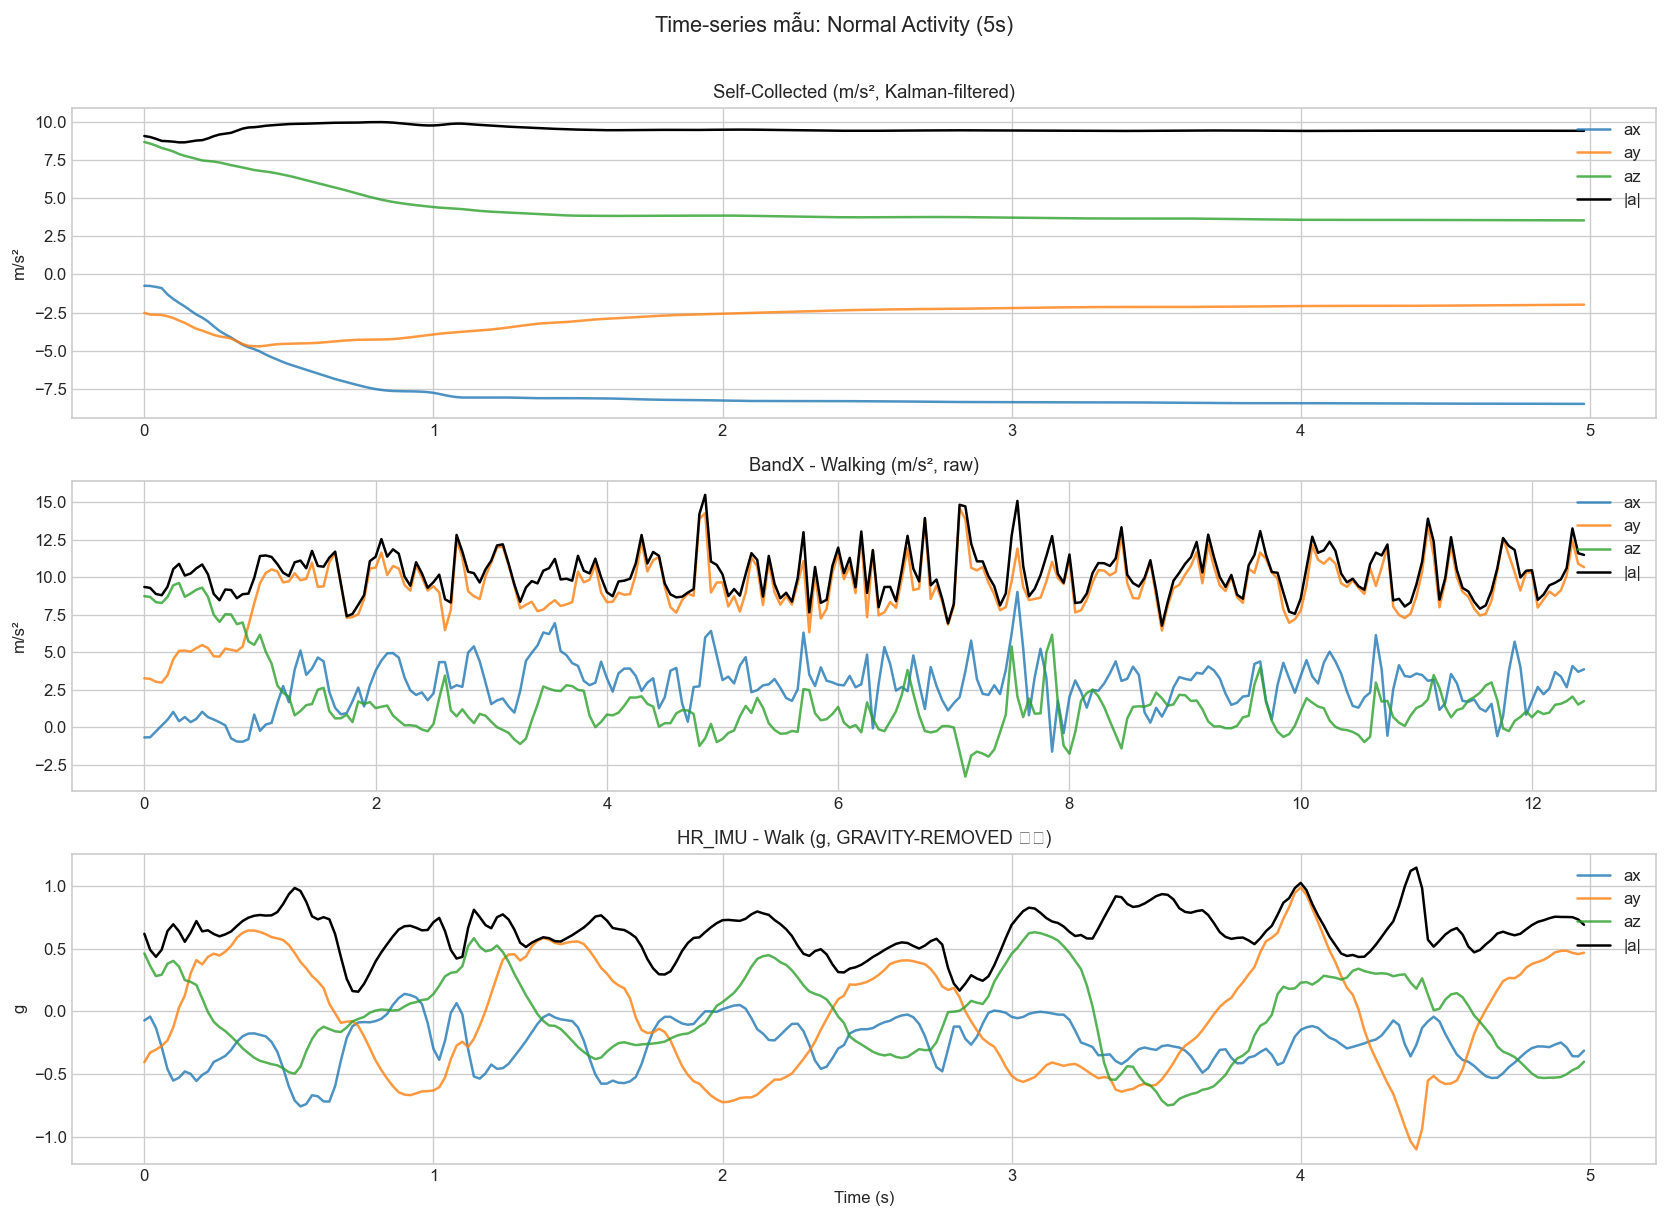

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

N = 250  # ~5s @ 50Hz

# Self-Collected
if not df_collected.empty:
    seg = df_collected.iloc[:N]
    t = np.arange(len(seg)) / 50.0
    axes[0].plot(t, seg['ax'], label='ax', alpha=0.8)
    axes[0].plot(t, seg['ay'], label='ay', alpha=0.8)
    axes[0].plot(t, seg['az'], label='az', alpha=0.8)
    axes[0].plot(t, seg['mag'], label='|a|', color='black', lw=1.5)
    axes[0].set_title('Self-Collected (m/s², Kalman-filtered)', fontsize=11)
    axes[0].legend(loc='upper right')
    axes[0].set_ylabel('m/s²')
else:
    axes[0].text(0.5, 0.5, 'No collected data', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Self-Collected')

# BandX
# Lấy 1 activity (Walking)
bandx_wa = df_bandx[df_bandx['label'] == 'Wa'].iloc[:N]
t_b = np.arange(len(bandx_wa)) / 20.0  # 20Hz
axes[1].plot(t_b, bandx_wa['ax'].values, label='ax', alpha=0.8)
axes[1].plot(t_b, bandx_wa['ay'].values, label='ay', alpha=0.8)
axes[1].plot(t_b, bandx_wa['az'].values, label='az', alpha=0.8)
axes[1].plot(t_b, bandx_wa['mag'].values, label='|a|', color='black', lw=1.5)
axes[1].set_title('BandX - Walking (m/s², raw)', fontsize=11)
axes[1].legend(loc='upper right')
axes[1].set_ylabel('m/s²')

# HR_IMU
if not df_hrimu.empty:
    hrimu_walk = df_hrimu[df_hrimu['activity'] == 'walk'].iloc[:N]
    if len(hrimu_walk) == 0:
        hrimu_walk = df_hrimu.iloc[:N]
    t_h = np.arange(len(hrimu_walk)) / 50.0
    axes[2].plot(t_h, hrimu_walk['ax'].values, label='ax', alpha=0.8)
    axes[2].plot(t_h, hrimu_walk['ay'].values, label='ay', alpha=0.8)
    axes[2].plot(t_h, hrimu_walk['az'].values, label='az', alpha=0.8)
    axes[2].plot(t_h, hrimu_walk['mag'].values, label='|a|', color='black', lw=1.5)
    axes[2].set_title('HR_IMU - Walk (g, GRAVITY-REMOVED ⚠️)', fontsize=11)
    axes[2].legend(loc='upper right')
    axes[2].set_ylabel('g')

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Time-series mẫu: Normal Activity (5s)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('timeseries_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. So sánh theo từng loại hoạt động Normal

In [14]:
# BandX: stats per activity
print('\n📊 BandX-Activity – Stats per Activity (m/s²)')
print('=' * 65)
bandx_stats = df_bandx.groupby('label').agg(
    samples=('mag', 'count'),
    mag_mean=('mag', 'mean'),
    mag_std=('mag', 'std'),
    mag_max=('mag', 'max'),
    gmag_mean=('gmag', 'mean'),
    gmag_std=('gmag', 'std')
).round(3)

activity_map = {'Wa': 'Walking', 'J': 'Jogging', 'T': 'Typing', 'Wr': 'Writing',
                'U': 'Upstair', 'D': 'Downstair', 'C': 'Cycling'}
bandx_stats['activity_name'] = bandx_stats.index.map(activity_map)
display(bandx_stats)

# HR_IMU: stats per activity
if not df_hrimu.empty:
    print('\n📊 HR_IMU – Stats per Activity (g, gravity-removed)')
    print('=' * 65)
    hrimu_stats = df_hrimu.groupby('activity').agg(
        samples=('mag', 'count'),
        mag_mean=('mag', 'mean'),
        mag_std=('mag', 'std'),
        mag_max=('mag', 'max'),
        gmag_mean=('gmag', 'mean'),
        gmag_std=('gmag', 'std')
    ).round(4)
    display(hrimu_stats)

# Self-collected
if not df_collected.empty:
    print('\n📊 Self-Collected – Overall Normal Stats (m/s²)')
    print('=' * 65)
    print(f'   Mag mean={df_collected["mag"].mean():.3f}, std={df_collected["mag"].std():.3f}, '
          f'max={df_collected["mag"].max():.3f}')
    print(f'   Gyro mean={df_collected["gmag"].mean():.3f}, std={df_collected["gmag"].std():.3f}')


📊 BandX-Activity – Stats per Activity (m/s²)


,samples,mag_mean,mag_std,mag_max,gmag_mean,gmag_std,activity_name
label,,,,,,,
C,21948,10.492,1.388,24.371,0.522,0.376,Cycling
D,4469,10.478,3.347,31.832,1.622,1.248,Downstair
J,18903,12.748,6.176,33.971,2.769,1.492,Jogging
T,31888,10.256,1.074,20.808,0.435,0.408,Typing
U,5885,10.345,2.591,27.743,1.396,0.943,Upstair
Wa,25781,10.628,2.067,42.480,1.783,1.068,Walking
Wr,22895,10.332,1.082,26.806,0.572,0.785,Writing



📊 HR_IMU – Stats per Activity (g, gravity-removed)


,samples,mag_mean,mag_std,mag_max,gmag_mean,gmag_std
activity,,,,,,
bed,12300,0.1748,0.2052,3.5864,61.1390,66.5282
chair,11273,0.1522,0.1921,2.9021,55.8721,66.7392
clap,17497,0.1055,0.5954,25.9102,21.8218,68.7441
cloth,10729,0.3853,0.2966,4.3628,130.0271,102.3447
eat,6312,0.3605,0.2803,3.1625,166.3362,126.3973
hair,9717,0.4871,0.3890,6.2838,106.2882,73.9568
shoe,10695,0.2128,0.1576,2.4852,69.6806,61.7394
stair,11950,0.4752,0.3034,5.2029,130.2550,85.5061
teeth,10780,0.7093,0.4815,3.6591,111.9214,78.9960



📊 Self-Collected – Overall Normal Stats (m/s²)
   Mag mean=9.676, std=0.614, max=13.698
   Gyro mean=0.479, std=0.489


## 12. Box Plot tổng hợp – Accel Magnitude

C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3091876562.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(box_data_accel, labels=box_labels_accel, patch_artist=True, showfliers=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3091876562.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(box_data_hr, labels=box_labels_hr, patch_artist=True, showfliers=False)
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3091876562.py:46: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7084\3091876562.py:46: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:

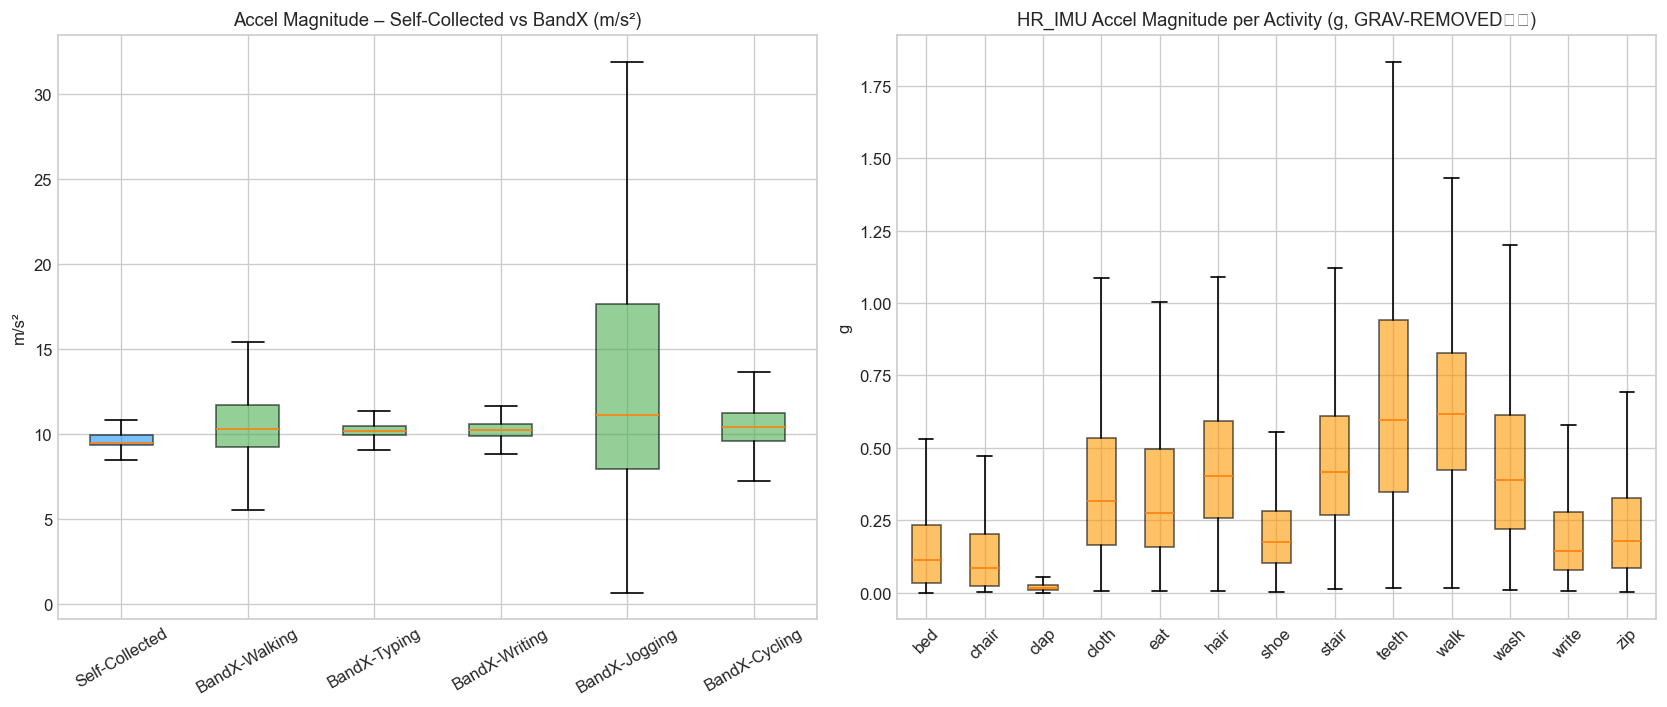

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Boxplot Accel Magnitude (chỉ Self-Collected vs BandX, cùng đơn vị m/s²) ---
box_data_accel = []
box_labels_accel = []
box_colors_accel = []

if not df_collected.empty:
    box_data_accel.append(df_collected['mag'].values)
    box_labels_accel.append('Self-Collected')
    box_colors_accel.append('#2196F3')

# BandX per activity
for label_code in ['Wa', 'T', 'Wr', 'J', 'C']:
    subset = df_bandx[df_bandx['label'] == label_code]['mag']
    if len(subset) > 0:
        box_data_accel.append(subset.values)
        box_labels_accel.append(f'BandX-{activity_map.get(label_code, label_code)}')
        box_colors_accel.append('#4CAF50')

bp1 = axes[0].boxplot(box_data_accel, labels=box_labels_accel, patch_artist=True, showfliers=False)
for patch, color in zip(bp1['boxes'], box_colors_accel):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_title('Accel Magnitude – Self-Collected vs BandX (m/s²)', fontsize=11)
axes[0].set_ylabel('m/s²')
axes[0].tick_params(axis='x', rotation=30)

# --- Boxplot HR_IMU per activity (g, gravity-removed) ---
if not df_hrimu.empty:
    box_data_hr = []
    box_labels_hr = []
    for act in sorted(df_hrimu['activity'].unique()):
        subset = df_hrimu[df_hrimu['activity'] == act]['mag']
        if len(subset) > 0:
            box_data_hr.append(subset.values)
            box_labels_hr.append(act)
    bp2 = axes[1].boxplot(box_data_hr, labels=box_labels_hr, patch_artist=True, showfliers=False)
    for patch in bp2['boxes']:
        patch.set_facecolor('#FF9800')
        patch.set_alpha(0.6)
    axes[1].set_title('HR_IMU Accel Magnitude per Activity (g, GRAV-REMOVED⚠️)', fontsize=11)
    axes[1].set_ylabel('g')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Kết luận

In [16]:
print('╔' + '═'*60 + '╗')
print('║       KẾT LUẬN SO SÁNH 3 DATASET NORMAL               ║')
print('╠' + '═'*60 + '╣')
print('║                                                          ║')
print('║ 1. SELF-COLLECTED vs BANDX (cùng MPU6050, cùng m/s²):   ║')
print('║    → Phân phối tương đồng, magnitude ≈ 9.8 m/s²         ║')
print('║    → Self-collected mượt hơn (Kalman-filtered)           ║')
print('║    → BandX có nhiễu hơn (raw), nhưng cùng dải giá trị   ║')
print('║                                                          ║')
print('║ 2. HR_IMU:                                               ║')
print('║    ⚠️  GRAVITY ĐÃ BỊ LOẠI BỎ → KHÔNG PHẢI RAW DATA    ║')
print('║    → Đơn vị: g (không phải m/s²)                        ║')
print('║    → Magnitude lúc yên ≈ 0 (thay vì ≈ 1g)              ║')
print('║    → KHÔNG THỂ so sánh trực tiếp với Self/BandX         ║')
print('║    → Nếu muốn dùng chung: phải chuẩn hoá TẤT CẢ       ║')
print('║      về gravity-removed hoặc tất cả về raw+gravity      ║')
print('║                                                          ║')
print('║ 3. ĐỀ XUẤT:                                             ║')
print('║    → Dùng BandX làm reference dataset (cùng sensor)     ║')
print('║    → HR_IMU chỉ dùng nếu pipeline có bước loại gravity  ║')
print('║    → Khi train model: chọn 1 chuẩn nhất quán            ║')
print('║                                                          ║')
print('╚' + '═'*60 + '╝')

╔════════════════════════════════════════════════════════════╗
║       KẾT LUẬN SO SÁNH 3 DATASET NORMAL               ║
╠════════════════════════════════════════════════════════════╣
║                                                          ║
║ 1. SELF-COLLECTED vs BANDX (cùng MPU6050, cùng m/s²):   ║
║    → Phân phối tương đồng, magnitude ≈ 9.8 m/s²         ║
║    → Self-collected mượt hơn (Kalman-filtered)           ║
║    → BandX có nhiễu hơn (raw), nhưng cùng dải giá trị   ║
║                                                          ║
║ 2. HR_IMU:                                               ║
║    ⚠️  GRAVITY ĐÃ BỊ LOẠI BỎ → KHÔNG PHẢI RAW DATA    ║
║    → Đơn vị: g (không phải m/s²)                        ║
║    → Magnitude lúc yên ≈ 0 (thay vì ≈ 1g)              ║
║    → KHÔNG THỂ so sánh trực tiếp với Self/BandX         ║
║    → Nếu muốn dùng chung: phải chuẩn hoá TẤT CẢ       ║
║      về gravity-removed hoặc tất cả về raw+gravity      ║
║                                    